# Exploratory Data Analysis — "To Vaccinate or Not to Vaccinate" (Zindi)

Formative Assignment 2, Research-Informed Sequential Models for NLP.

This notebook does the EDA for Section 1 of the brief, for our chosen challenge:
Sentiment Analysis: To Vaccinate or Not to Vaccinate. The task is to classify a
tweet's sentiment about vaccines as:

- `-1` — Negative (anti-vaccine)
- `0` — Neutral
- `1` — Positive (pro-vaccine)

Each tweet also has an `agreement` score (0.33-1.0), the fraction of annotators who
agreed on the label — a useful proxy for how noisy or ambiguous that label is.

We're treating this as a 3-class sequential text classification problem: a tweet is a
sequence of tokens whose order and local context (negation, sarcasm, hashtags) is what
actually determines sentiment — exactly the kind of dependency RNN/Transformer-style
models are built to capture. That's why the analysis below focuses on properties of the
sequences themselves — length, vocabulary, noise, class balance — rather than generic
tabular stats.


In [1]:
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import STOPWORDS, WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

DATA_DIR = Path("../data/raw")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 1. Load the data

In [2]:
train = pd.read_csv(DATA_DIR / "Train.csv")
test = pd.read_csv(DATA_DIR / "Test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (10001, 4)
Test shape : (5177, 2)


,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tweet_id   10001 non-null  str    
 1   safe_text  10001 non-null  str    
 2   label      10000 non-null  float64
 3   agreement  9999 non-null   float64
dtypes: float64(2), str(2)
memory usage: 1.3 MB


## 2. Data quality checks

Before anything else: missing values, duplicate rows/ids, and malformed rows (e.g. a
stray comma breaking the CSV parse), since these directly affect how many usable
sequences we actually have to train on.

In [4]:
print("Missing values (train):")
print(train.isna().sum())
print()
print("Missing values (test):")
print(test.isna().sum())


Missing values (train):
tweet_id     0
safe_text    0
label        1
agreement    2
dtype: int64

Missing values (test):
tweet_id     0
safe_text    1
dtype: int64


In [5]:
# Rows with missing text or label are unusable for sequence modelling -> flag them
bad_rows = train[train['safe_text'].isna() | train['label'].isna()]
print(f"Rows with missing text/label in train: {len(bad_rows)}")
bad_rows


Rows with missing text/label in train: 1


,tweet_id,safe_text,label,agreement
4798,RQMQ0L2A,#lawandorderSVU,NaN,NaN


In [6]:
# Duplicate tweet_ids and duplicate raw text (near-duplicate sequences add redundancy /
# can leak between train-val splits if not handled)
print("Duplicate tweet_id count:", train['tweet_id'].duplicated().sum())
print("Duplicate safe_text count:", train['safe_text'].duplicated().sum())

dup_examples = train[train['safe_text'].duplicated(keep=False)].sort_values('safe_text')
dup_examples.head(10)


Duplicate tweet_id count: 0
Duplicate safe_text count: 343


,tweet_id,safe_text,label,agreement
1993,Y57DZH1R,"""<user> Nationalism is an infantile disease. I...",0.0,1.000000
4969,EEJ1ANAV,"""<user> Nationalism is an infantile disease. I...",0.0,1.000000
2069,T93G6RMA,"""<user> On average, people who complain live l...",0.0,1.000000
4795,XG1NCFF0,"""<user> On average, people who complain live l...",0.0,1.000000
4615,F0J5MD1B,"""<user> Share this tweet, and thank a health w...",1.0,1.000000
7333,LO9J4C7U,"""<user> Share this tweet, and thank a health w...",1.0,1.000000
2934,9C08NX5A,"""Love\n\nis a measles and everyone has to go t...",0.0,1.000000
5599,WCDN1ZSY,"""Love\n\nis a measles and everyone has to go t...",0.0,1.000000
190,NH3YCR4A,"""MMR Meets Bliss"" \nThurSday AUGUST 20\n#Lad...",0.0,1.000000
9641,XKRKVQ21,"""MMR Meets Bliss"" \nThurSday AUGUST 20\n#Lad...",0.0,0.666667


In [7]:
# Clean copy used for the rest of the EDA (drop the unusable row(s) only)
train_clean = train.dropna(subset=['safe_text', 'label']).copy()
train_clean['label'] = train_clean['label'].astype(int)
print("Usable training rows:", len(train_clean), "/", len(train))


Usable training rows: 10000 / 10001


In [8]:
# Duplicate *text* with CONFLICTING labels is a stronger, more direct signal of label
# noise than the agreement score alone: the exact same sentence was independently
# annotated with different sentiments in different rows.
dup_groups = train_clean[train_clean.duplicated('safe_text', keep=False)]
label_nunique = dup_groups.groupby('safe_text')['label'].nunique()
conflicting = label_nunique[label_nunique > 1]

print(f"Duplicate-text groups (identical tweet, appears >1 time): {dup_groups['safe_text'].nunique()}")
print(f"...of which have CONFLICTING labels across duplicates: {len(conflicting)} "
      f"({len(conflicting)/dup_groups['safe_text'].nunique():.1%})")
print()
example_text = conflicting.index[0]
train_clean[train_clean['safe_text'] == example_text][['tweet_id', 'label', 'agreement']]


Duplicate-text groups (identical tweet, appears >1 time): 155
...of which have CONFLICTING labels across duplicates: 36 (23.2%)



,tweet_id,label,agreement
1922,4G89WQE1,1,0.666667
4179,WLG662AB,0,0.666667
4380,JR5FHRSL,1,1.000000


## 3. Class distribution & label agreement

Class balance matters a lot here — a skewed distribution biases the model toward the
majority class and needs addressing (class weights, resampling, or just using macro-F1
instead of accuracy). The `agreement` score tells us how noisy the labels are — tweets
with low agreement are inherently ambiguous (sarcasm, mixed sentiment) and should be
harder for any model to learn from correctly.

            count  percent
label_name                
Negative     1038     10.4
Neutral      4909     49.1
Positive     4053     40.5

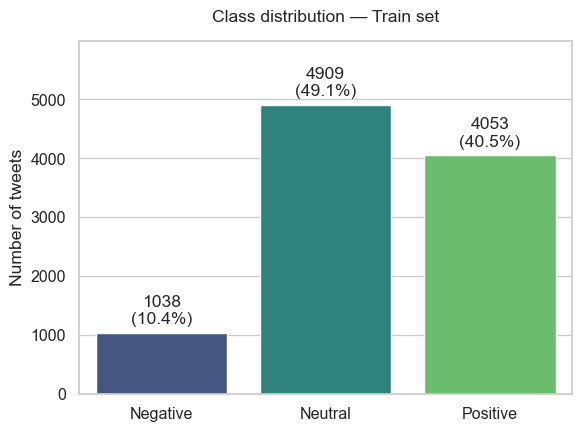

In [9]:
label_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
train_clean['label_name'] = train_clean['label'].map(label_map)

counts = train_clean['label_name'].value_counts().reindex(["Negative", "Neutral", "Positive"])
pct = (counts / counts.sum() * 100).round(1)
print(pd.DataFrame({"count": counts, "percent": pct}))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(x=counts.index, y=counts.values, palette="viridis", ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.03, f"{v}\n({pct.values[i]}%)", ha='center')
ax.set_ylim(top=counts.max() * 1.22)
ax.set_title("Class distribution — Train set", pad=14)
ax.set_ylabel("Number of tweets")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_distribution.png", dpi=150)
plt.show()


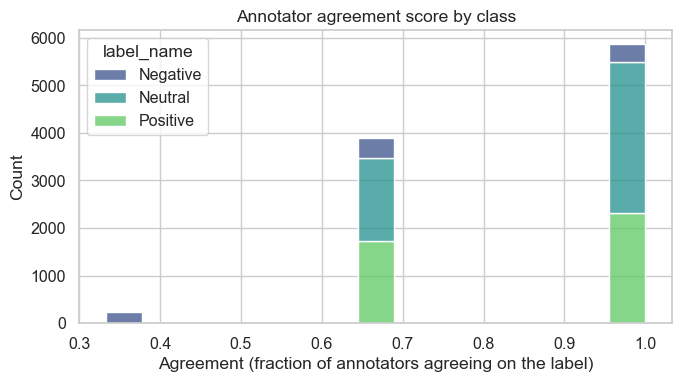

Mean agreement overall: 0.854
label_name
Negative    0.713
Neutral     0.881
Positive    0.858
Name: agreement, dtype: float64

Fraction of tweets with agreement < 0.6 (i.e. ambiguous/noisy labels): 2.4%


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=train_clean, x='agreement', hue='label_name', multiple='stack',
             bins=15, hue_order=["Negative", "Neutral", "Positive"], palette="viridis", ax=ax)
ax.set_title("Annotator agreement score by class")
ax.set_xlabel("Agreement (fraction of annotators agreeing on the label)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_agreement_by_class.png", dpi=150)
plt.show()

print("Mean agreement overall:", round(train_clean['agreement'].mean(), 3))
print(train_clean.groupby('label_name')['agreement'].mean().round(3))
print()
low_agreement_frac = (train_clean['agreement'] < 0.6).mean()
print(f"Fraction of tweets with agreement < 0.6 (i.e. ambiguous/noisy labels): {low_agreement_frac:.1%}")


## 4. Sequence length distribution

Tweets are short, but our models still need a fixed max length for batching, so we
look at both character counts and word counts, overall and by class. This sets the
padding/truncation length and gives an early signal on whether length itself
correlates with sentiment.

In [11]:
train_clean['char_len'] = train_clean['safe_text'].str.len()
train_clean['word_len'] = train_clean['safe_text'].str.split().str.len()

print(train_clean[['char_len', 'word_len']].describe().round(1))


       char_len  word_len
count   10000.0   10000.0
mean       99.9      16.3
std        29.9       5.3
min         1.0       1.0
25%        79.8      13.0
50%       107.0      17.0
75%       122.0      20.0
max       153.0      33.0


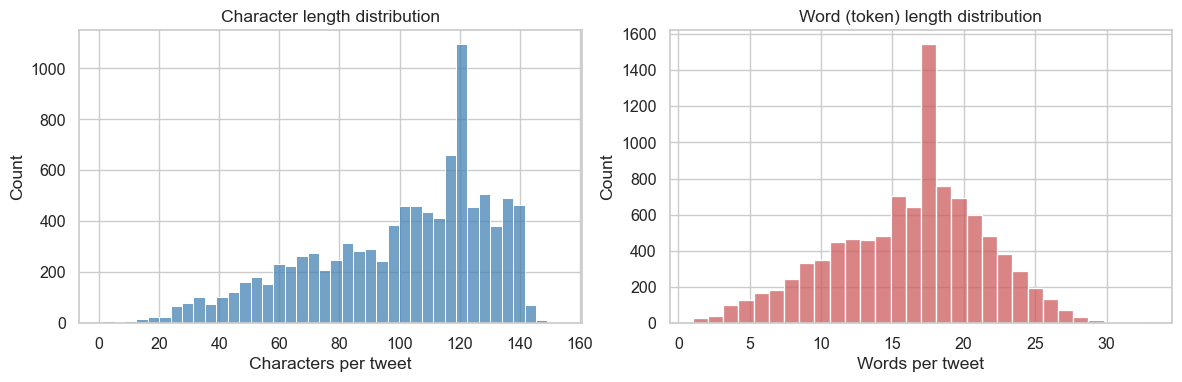

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_clean['char_len'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title("Character length distribution")
axes[0].set_xlabel("Characters per tweet")

sns.histplot(train_clean['word_len'], bins=30, ax=axes[1], color='indianred')
axes[1].set_title("Word (token) length distribution")
axes[1].set_xlabel("Words per tweet")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_length_distributions.png", dpi=150)
plt.show()


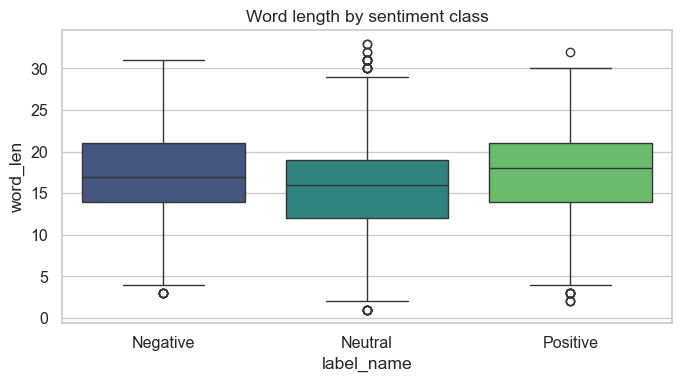

             count  mean  std  min   25%   50%   75%   max
label_name                                                
Negative    1038.0  16.9  5.2  3.0  14.0  17.0  21.0  31.0
Neutral     4909.0  15.5  5.5  1.0  12.0  16.0  19.0  33.0
Positive    4053.0  17.0  5.1  2.0  14.0  18.0  21.0  32.0


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train_clean, x='label_name', y='word_len',
            order=["Negative", "Neutral", "Positive"], palette="viridis", ax=ax)
ax.set_title("Word length by sentiment class")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_wordlen_by_class.png", dpi=150)
plt.show()

print(train_clean.groupby('label_name')['word_len'].describe().round(1))


In [14]:
# 95th/99th percentile word length -> informs max_seq_len for padding/truncation
for p in [90, 95, 99, 100]:
    print(f"{p}th percentile word length:", np.percentile(train_clean['word_len'], p))


90th percentile word length: 23.0
95th percentile word length: 24.0
99th percentile word length: 27.0
100th percentile word length: 33.0


## 5. Text noise: anonymisation tokens, URLs, hashtags, mentions, emojis

Tweets here are already anonymised by Zindi (usernames become `<user>`, links become
`<url>`). We check how often these placeholders show up (they're generic, low-
information tokens a tokenizer should probably special-case or strip), along with
hashtag/mention density, emoji usage, and ALL-CAPS "shouting" — all common sources of
social-media noise that preprocessing needs to handle explicitly.

In [15]:
def count_pattern(series, pattern):
    return series.str.count(pattern)

train_clean['n_user'] = count_pattern(train_clean['safe_text'], r'<user>')
train_clean['n_url'] = count_pattern(train_clean['safe_text'], r'<url>')
train_clean['n_hashtag'] = count_pattern(train_clean['safe_text'], r'#\w+')
train_clean['n_mention_raw'] = count_pattern(train_clean['safe_text'], r'@\w+')  # rare, most are already <user>
train_clean['n_exclaim'] = count_pattern(train_clean['safe_text'], r'!')
train_clean['n_question'] = count_pattern(train_clean['safe_text'], r'\?')
train_clean['has_allcaps_word'] = train_clean['safe_text'].apply(
    lambda t: any(w.isupper() and len(w) > 2 for w in re.findall(r"[A-Za-z']+", t))
)
train_clean['has_html_entity'] = train_clean['safe_text'].str.contains(
    r'&amp;|&lt;|&gt;|&#\d+;', regex=True
)

noise_summary = pd.DataFrame({
    'tweets_with_<user>': [(train_clean['n_user'] > 0).mean()],
    'tweets_with_<url>': [(train_clean['n_url'] > 0).mean()],
    'tweets_with_hashtag': [(train_clean['n_hashtag'] > 0).mean()],
    'tweets_with_raw_@mention': [(train_clean['n_mention_raw'] > 0).mean()],
    'tweets_with_ALLCAPS_word': [train_clean['has_allcaps_word'].mean()],
    'tweets_with_undecoded_HTML_entity': [train_clean['has_html_entity'].mean()],
}).T.rename(columns={0: 'fraction_of_tweets'})
noise_summary['fraction_of_tweets'] = (noise_summary['fraction_of_tweets'] * 100).round(1)
noise_summary


,fraction_of_tweets
tweets_with_<user>,40.4
tweets_with_<url>,43.7
tweets_with_hashtag,26.6
tweets_with_raw_@mention,0.0
tweets_with_ALLCAPS_word,24.6
tweets_with_undecoded_HTML_entity,5.9


Note on HTML entities: a fair number of tweets still have raw HTML entities like
`&amp;`. These are a leftover from the original scraping pipeline, and if left as-is
they get split into meaningless sub-tokens (`&`, `amp`, `;`) by a naive tokenizer. An
easy fix — unescape every tweet — that all five of our approaches should apply.

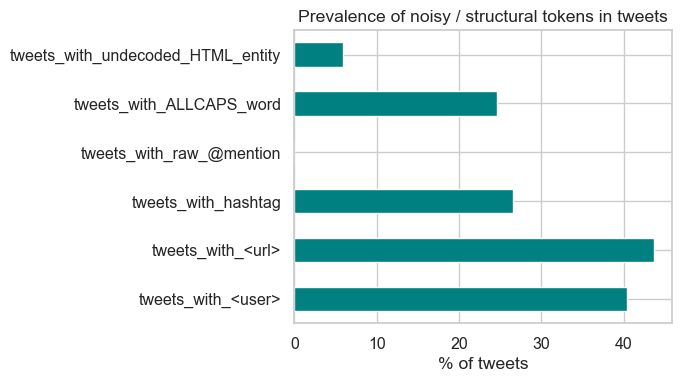

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
noise_summary['fraction_of_tweets'].plot(kind='barh', color='teal', ax=ax)
ax.set_xlabel("% of tweets")
ax.set_title("Prevalence of noisy / structural tokens in tweets")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_noise_tokens.png", dpi=150)
plt.show()


## 6. Vocabulary analysis

A simple whitespace-and-punctuation tokenizer (no external library needed just for
EDA) gets us vocabulary size, type-token ratio, and the most frequent words overall and
per class, with `<user>`/`<url>` and stopwords stripped out so the sentiment-bearing
vocabulary is actually visible. A large vocabulary relative to corpus size, plus a long
tail of rare words, both point toward subword tokenization over a fixed word-level one.

In [17]:
STOP = set(STOPWORDS) | {'user', 'url', 'amp', 'rt'}

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'<user>|<url>', ' ', text)
    text = re.sub(r"[^a-z0-9#'\s]", ' ', text)
    tokens = text.split()
    return [t for t in tokens if t not in STOP and len(t) > 1]

train_clean['tokens'] = train_clean['safe_text'].apply(simple_tokenize)
all_tokens = [tok for toks in train_clean['tokens'] for tok in toks]
vocab = Counter(all_tokens)

print("Total tokens (content words):", len(all_tokens))
print("Vocabulary size (unique content words):", len(vocab))
print(f"Type-token ratio: {len(vocab) / len(all_tokens):.4f}")

singleton_words = sum(1 for _, c in vocab.items() if c == 1)
print(f"Words occurring exactly once: {singleton_words} ({singleton_words/len(vocab):.1%} of vocabulary)")


Total tokens (content words): 93278
Vocabulary size (unique content words): 14236
Type-token ratio: 0.1526
Words occurring exactly once: 8026 (56.4% of vocabulary)


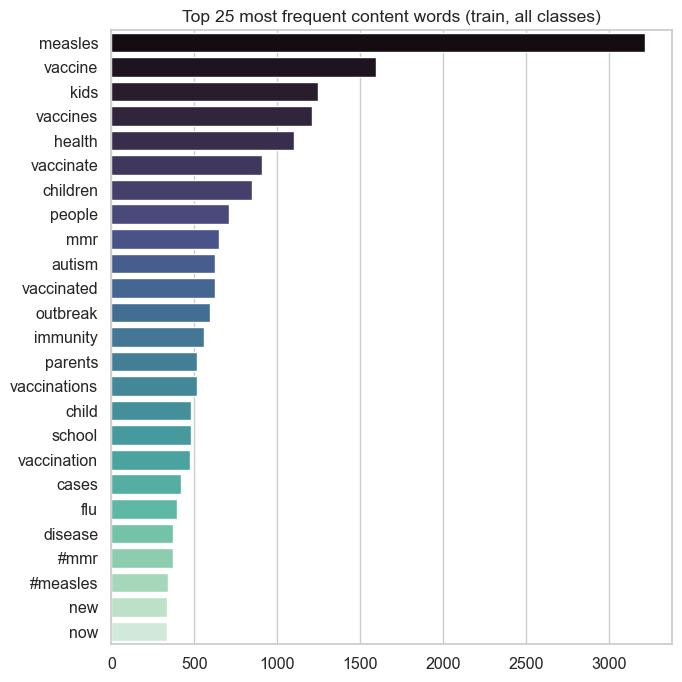

In [18]:
top_overall = vocab.most_common(25)
fig, ax = plt.subplots(figsize=(7, 7))
words, freqs = zip(*top_overall)
sns.barplot(x=list(freqs), y=list(words), palette="mako", ax=ax)
ax.set_title("Top 25 most frequent content words (train, all classes)")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_top_words_overall.png", dpi=150)
plt.show()


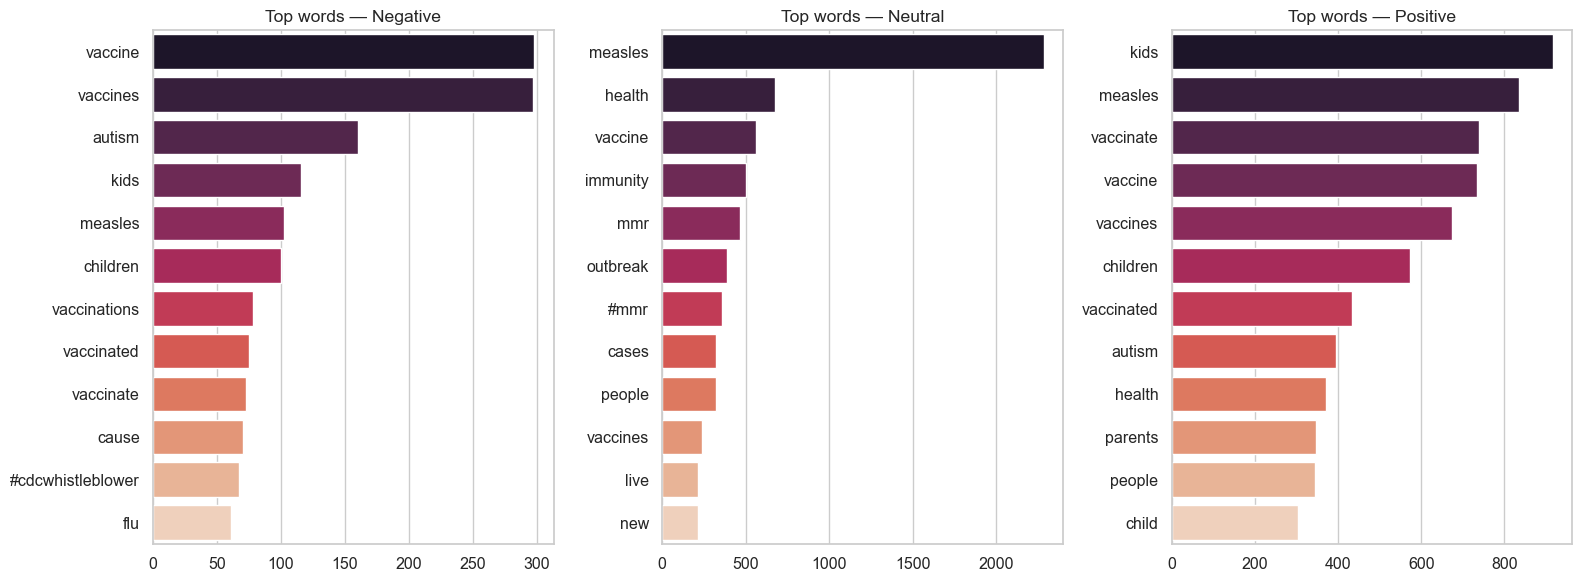

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (lbl, name) in zip(axes, label_map.items()):
    subset_tokens = [tok for toks in train_clean.loc[train_clean['label'] == lbl, 'tokens'] for tok in toks]
    top = Counter(subset_tokens).most_common(12)
    words, freqs = zip(*top) if top else ([], [])
    sns.barplot(x=list(freqs), y=list(words), palette="rocket", ax=ax)
    ax.set_title(f"Top words — {name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_top_words_by_class.png", dpi=150)
plt.show()


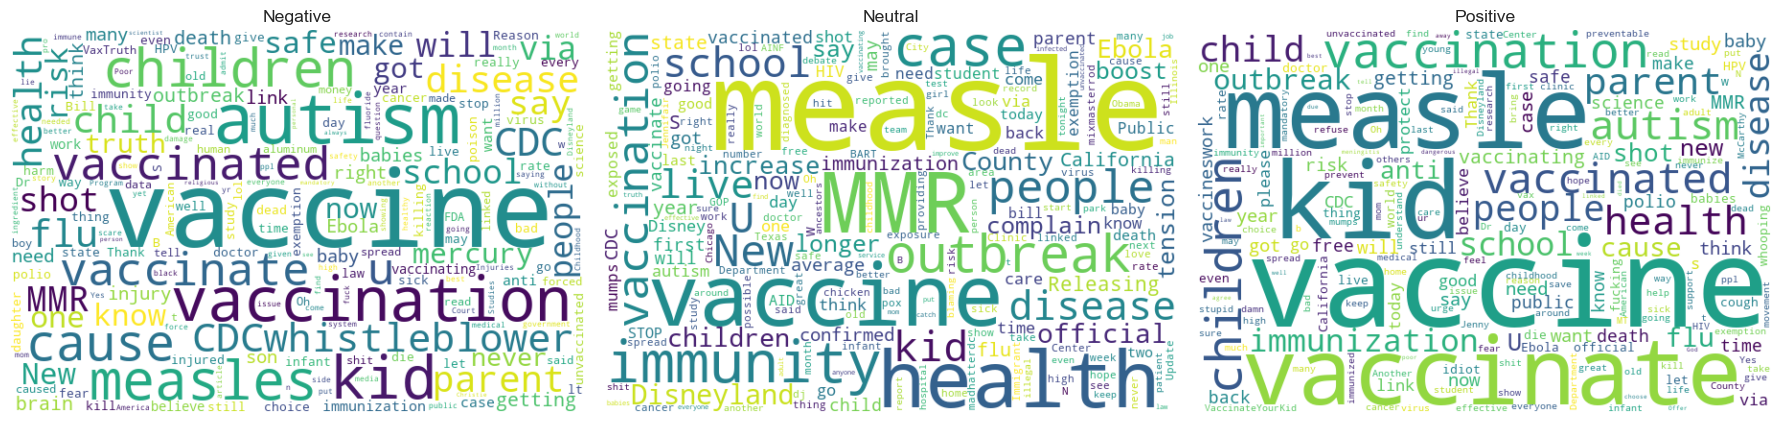

In [20]:
# Word clouds per class — quick qualitative view of class-distinguishing vocabulary
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (lbl, name) in zip(axes, label_map.items()):
    text_blob = ' '.join(train_clean.loc[train_clean['label'] == lbl, 'safe_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                    stopwords=STOP, collocations=False).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / "08_wordclouds_by_class.png", dpi=150)
plt.show()


Finding — vocabulary overlap across classes: the three word clouds share the same core
vocabulary (`vaccine`, `measles`, `vaccinate`, `children`, `MMR`, `autism`, `health`),
which makes sense since all three classes are, by definition, about vaccines. The real
signal is subtler — `autism` and `cause` are prominent in the Negative cloud (anti-
vaccine rhetoric linking vaccines to autism), while `science`, `safe`, and `work` skew
Positive. This confirms a simple keyword-presence classifier is going to struggle here,
because the same topical words show up regardless of sentiment — what differs is how
they're combined. That's fairly direct evidence for sequence-aware models over anything
that only sees word presence/absence.

In [21]:
# Hashtags specifically — useful signal, often topical rather than sentiment-bearing
hashtags = re.findall(r'#\w+', ' '.join(train_clean['safe_text']).lower())
top_hashtags = Counter(hashtags).most_common(20)
pd.DataFrame(top_hashtags, columns=['hashtag', 'count'])


,hashtag,count
0,#mmr,373
1,#measles,341
2,#vaccineswork,146
3,#vaccines,122
4,#vaccine,98
5,#ebola,83
6,#cdcwhistleblower,74
7,#autism,73
8,#vaccinate,70
9,#health,57


### 6.1 A hashtag collision: `#mmr`

`#mmr` is the single most frequent hashtag in the dataset, ahead of even `#measles`.
MMR is the standard abbreviation for the Measles-Mumps-Rubella vaccine, which is almost
certainly why the data-collection query picked it up. But MMR is also an unrelated
abbreviation used by a DJ/radio-promotion community ("#MMR", "#MMR-B-Q", club flyers)
and by run-tracking apps (distance in miles). Worth checking whether `#mmr` tweets here
are actually about vaccines.

In [22]:
mmr_rows = train_clean[train_clean['safe_text'].str.contains('#mmr', case=False)]
print(f"Tweets containing #mmr: {len(mmr_rows)} ({len(mmr_rows)/len(train_clean):.1%} of training data)")
print()
print("Label distribution within #mmr tweets:")
print(mmr_rows['label_name'].value_counts())
print()
print("Sample #mmr tweets:")
for t in mmr_rows['safe_text'].sample(8, random_state=RANDOM_STATE):
    print("-", t.replace(chr(10), ' ')[:110])


Tweets containing #mmr: 378 (3.8% of training data)

Label distribution within #mmr tweets:
label_name
Neutral     360
Positive     14
Negative      4
Name: count, dtype: int64

Sample #mmr tweets:
- Tailgating done right .rain never stops us.MMR•B•Q music festival 2016. #MMRBQ2016 gr8bands gr8times with gr8f
- S/O my radio #teamfollowdatbag <user> #MMR #FDB #datbag will be a host this week live. Follow my… <url>
- #MMR video , Wass funny a'f !! 
- Cause 2night is the Night... #EazyBash #BlackOnBlack #Erything #ItsShowTime #Venue #MMR… <url>
- : NEW {MUSIC} from #MMR Jennifair - Crack produced by DrumMage! <user> <url>
- Back at SoBe Come Show Love... #mmr #dmv #dj #instava #va #nattybo #top40 #edm #remixes #fun… <url>
- My camp is the cutest 😍 #mmr #camp @ California <url>
- Counting down the minutes, come on baby! #mmr <user> I think you should just start pushing.


Finding: ~95% of `#mmr` tweets are labelled Neutral, and manual inspection confirms
most are off-topic — DJ sets, club nights, running apps — that just happen to share the
string "MMR" with the vaccine abbreviation. This looks like a real keyword-collision
issue inherited from how the dataset was probably assembled (querying for "MMR" among
other vaccine terms). In practice this means:
- A chunk of the "Neutral" class isn't actually about vaccine sentiment at all — it's
  topically unrelated text that's trivially non-sentiment-bearing.
- A model that leans too hard on the `#mmr` token is learning a data-collection
  artefact, not sentiment — worth flagging specifically if `#mmr` tweets turn out to
  be systematically misclassified later.
- It also reinforces why hashtag-level features alone aren't enough — the model needs
  to read the whole sequence, not just trigger on one keyword.

## 7. Bigram analysis

Sentiment often comes down to short local phrases (negation + verb, or something like
"anti vax") that unigram counts miss entirely. We look at the most frequent bigrams
overall and by class to check this, and to confirm sequence-aware models — which can
pick up local dependencies like this implicitly — actually make sense here.

In [23]:
def get_bigrams(tokens):
    return list(zip(tokens, tokens[1:]))

all_bigrams = Counter(bg for toks in train_clean['tokens'] for bg in get_bigrams(toks))
top_bigrams = all_bigrams.most_common(20)
pd.DataFrame([(f"{a} {b}", c) for (a, b), c in top_bigrams], columns=['bigram', 'count'])


,bigram,count
0,measles outbreak,457
1,vaccinate kids,352
2,health officials,228
3,measles cases,226
4,vaccinate children,194
5,live longer,171
6,increases immunity,171
7,tension increases,170
8,complain live,167
9,longer releasing,165


## 8. Code-switching, spelling variation, and non-English content (proxy checks)

We don't have a proper language identifier installed, so we use rough proxies instead:
the fraction of tokens that look non-standard (non-ASCII, or repeated-letter "shouting"
spellings like `soooo`), plus a manual look at a sample of tweets with common slang
markers. This flags spelling variation, elongated words, and informal/slang tokens —
all things a subword tokenizer handles far more gracefully than a fixed vocabulary.

In [24]:
def has_elongation(text):
    # 3+ repeated letters in a row, e.g. 'soooo', 'nooo'
    return bool(re.search(r'([a-zA-Z])\1{2,}', text))

train_clean['has_elongation'] = train_clean['safe_text'].apply(has_elongation)
print(f"Tweets with elongated/expressive spelling (e.g. 'soooo'): {train_clean['has_elongation'].mean():.1%}")

# Sample a few examples for qualitative inspection
train_clean.loc[train_clean['has_elongation'], ['safe_text', 'label_name']].sample(5, random_state=RANDOM_STATE)


Tweets with elongated/expressive spelling (e.g. 'soooo'): 1.2%


,safe_text,label_name
3926,"""<user> <user> Shiiit I got my shot.""the stupi...",Positive
3995,"Pizza Slice- ""I was just insulted.""\n\nMe- ""Wh...",Neutral
498,Mmmmmhmmmm all these sick kids are kids I trie...,Positive
4486,*extremely paranoid white person voyce*\nIm br...,Neutral
2502,100 red dots on his body like he got the measl...,Neutral


In [25]:
non_ascii_frac = train_clean['safe_text'].apply(lambda t: any(ord(c) > 127 for c in t)).mean()
print(f"Tweets containing non-ASCII characters (emoji, accented/non-English script, etc.): {non_ascii_frac:.1%}")


Tweets containing non-ASCII characters (emoji, accented/non-English script, etc.): 22.3%


## 9. Train vs. test comparison

Checking whether test has similar length and vocabulary characteristics to train, and
estimating the out-of-vocabulary rate — how many test-set words never show up in
training. A high OOV rate is more evidence for subword/character-aware models, which
degrade far more gracefully than word-level models on unseen tokens.

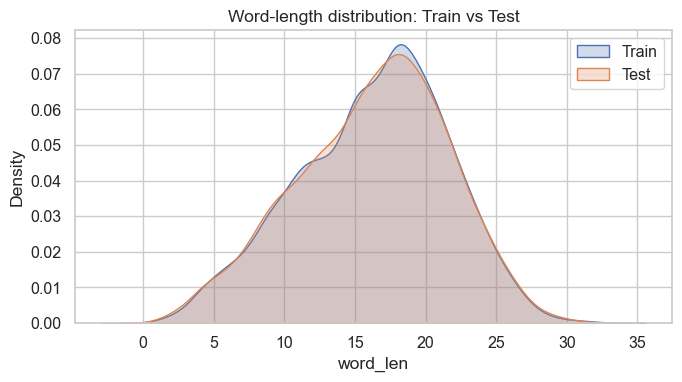

Train word_len mean/median: 16.3 17.0
Test  word_len mean/median: 16.2 17.0


In [26]:
test['word_len'] = test['safe_text'].fillna('').str.split().str.len()
test['char_len'] = test['safe_text'].fillna('').str.len()

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(train_clean['word_len'], label='Train', fill=True, ax=ax)
sns.kdeplot(test['word_len'], label='Test', fill=True, ax=ax)
ax.set_title("Word-length distribution: Train vs Test")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "09_train_vs_test_length.png", dpi=150)
plt.show()

print("Train word_len mean/median:", train_clean['word_len'].mean().round(1), train_clean['word_len'].median())
print("Test  word_len mean/median:", test['word_len'].mean().round(1), test['word_len'].median())


In [27]:
test_tokens = set(tok for text in test['safe_text'].fillna('') for tok in simple_tokenize(text))
train_vocab_set = set(vocab.keys())
oov = test_tokens - train_vocab_set
print(f"Test vocabulary size: {len(test_tokens)}")
print(f"Out-of-vocabulary words (in test, unseen in train): {len(oov)} ({len(oov)/len(test_tokens):.1%})")
list(oov)[:20]


Test vocabulary size: 9835
Out-of-vocabulary words (in test, unseen in train): 3903 (39.7%)


['vowel',
 '#authenticity',
 'youve',
 'serenading',
 'cone',
 'surrounds',
 'prj',
 'famine',
 'radificaction',
 'trunk',
 'mika',
 'comiccon',
 'mariah',
 'nag',
 'reals',
 'sorts',
 '#potentialbandname',
 'probiotics',
 'outskirts',
 '#tylenol']

## 10. Summary of findings and what they mean for model selection

| Finding | What it means for modelling |
|---|---|
| Classes are imbalanced: Neutral 49.1%, Positive 40.5%, Negative 10.4% | Macro-F1 over accuracy; class-weighted loss and/or oversampling for the neural models. |
| Agreement averages 0.854 overall but drops to 0.713 for Negative | Negative is both the rarest and the most disputed class — expect it to be the hardest for every model and a focus of the error analysis. |
| 155 duplicate-text groups, 36 (23%) with conflicting labels on the identical tweet | Real label noise, not just annotator fuzziness — the same sentence got different labels in different rows. Caps the achievable F1 regardless of model, and needs de-duping before any split to avoid leakage. |
| Tweets are short — median 17 words / 107 characters, 95% under 24 words | A `max_seq_len` around 24-32 balances keeping information against wasting padding. |
| `<user>` (40.4%), `<url>` (43.7%), hashtags (26.6%), and ALL-CAPS words (24.6%) are everywhere | Worth mapping to dedicated tokens rather than letting them pollute the vocabulary. |
| 5.9% of tweets still have raw HTML entities (`&amp;`, `&lt;`) | Cheap fix — unescape before tokenizing, across all five approaches. |
| `#mmr` is the single most frequent hashtag, but ~95% of those tweets are Neutral and mostly off-topic (DJ/radio and running-app content sharing the string "MMR") | A genuine data-collection artefact — a chunk of "Neutral" isn't really about vaccines. Models that lean on this token risk learning the artefact instead of sentiment. |
| 14,236 unique content words, 56.4% appearing only once; 22.3% of tweets have non-ASCII characters | Favours subword tokenization (WordPiece/BPE) over a fixed word-level vocabulary, since it degrades more gracefully on rare or unseen tokens. |
| 39.7% of test-set content words never appear in the training vocabulary | Same point again — a word-level embedding table trained only on train will hit a lot of unknowns at test time; pretrained subword embeddings help a lot here. |
| Sentiment-relevant bigrams (`vaccinate kids`, `cause autism`, `measles outbreak`) dominate the bigram counts, alongside one heavily duplicated copypasta tweet | Supports architectures that model local dependencies (CNN/RNN) and longer-range context (attention/Transformer) over a bag-of-words assumption; also shows the duplication problem turning up even in aggregate n-gram stats. |

These are what actually drove the five approaches picked in the Related Work / Model
Selection section: two classical bag-of-words baselines (TF-IDF + Logistic Regression,
TF-IDF + Linear SVM) to see how much a non-sequential model already captures, plus
three neural sequential models — a BiLSTM with learned embeddings, a CNN-BiGRU hybrid
with attention, and a fine-tuned transformer (DistilBERT) — that can exploit word
order, local n-grams, and long-range context respectively.
